In [60]:
import os
os.environ["JAX_PLATFORMS"] = 'cpu'
import jax.numpy as jnp
import jax 
import numpy as np
from utils import (
                  syn_group_id_paths_for_sem_data,
                  sem_ids_with_syn_path,
                  syn_syn_ids_path,
                  collect_data,
                  torch_to_jax,
                  flatten_tokens_features,
                  depths,
                  reduce_list_half_preserve_extremes,
                  remove_syn_group_averages,
                  load_and_subtract_syn_group_averages,
                  load_sem_centers,
                  get_syn_centroids_folder,
                  load_syn_group_averages,
                  batched_remove_centroid_projections,
                   )
from geometry import normalized_L2_distance
from datapaths import * 
import matplotlib.pyplot as plt
from torch import from_numpy


def compute_rowwise_cosine_similarity(act_A, act_B, eps=1e-8):
    """
    Compute row-wise cosine similarity between two activation matrices.

    Args:
        act_A (jnp.ndarray): shape (N, D), activations from space A
        act_B (jnp.ndarray): shape (N, D), activations from space B
        eps (float): small constant to avoid division by zero

    Returns:
        jnp.ndarray: shape (N,), cosine similarities for each row pair
    """
    numerator = jnp.sum(act_A * act_B, axis=1)
    denominator = jnp.linalg.norm(act_A, axis=1) * jnp.linalg.norm(act_B, axis=1)
    return numerator / (denominator + eps)


In [2]:
avg_tokens = 1
min_token_length = 3 if avg_tokens == 0 else -1
n_tokens = min_token_length 
n_files = 21
model_name = 'deepseek'
precision = 32
data_var = 'sem'

input_path_A = input_paths['english'][model_name]['matching']['0'][data_var]
input_path_B = input_paths['english'][model_name]['matching']['1'][data_var]

In [3]:
all_activations_A = collect_data(input_path_A, 
            min_token_length, 
            n_files,
            model_name,
            avg_tokens,
            )
# all_activations_B = collect_data(input_path_B, 
#             min_token_length, 
#             n_files,
#             model_name,
#             avg_tokens,
#             )

deepseek dtype: torch.bfloat16


Collect File: 100%|██████████| 21/21 [00:07<00:00,  2.88it/s]


all_hidden_states["layer_0"].shape=torch.Size([2018, 7168])
importing took 0.13309916257858276 m


In [53]:
def preprocessing(all_activations, layer, space_index, global_center_flag,avg_tokens, verbose=False):


  # syn_syn_indices = jnp.array(np.loadtxt(syn_syn_ids_path,dtype=int),dtype=jnp.int32) # filtering data to ALSO have their syntax group in space B

  # act = {}
  # centroids = {}
  # global_center = {}

  # loading data
  _all_activations = all_activations[f"layer_{layer}"]
  if avg_tokens == 0:
    _all_activations = _all_activations[:,-n_tokens:,:]
    _all_activations = flatten_tokens_features(_all_activations)
  
  act = torch_to_jax(_all_activations,precision)

  # globally centering data [with all samples]
  if global_center_flag:
      global_center = jnp.mean(act,axis=0)
      act = act - jnp.broadcast_to(global_center,act.shape)
  else:
      global_center = None

  
  sim_folder = f"/home/acevedo/syn-sem/results/global_centering_0/spaces_AB/similarity_fn_normalized_L2_distance/precision_32/language_english/data_var_syn/modelA_{model_name}/modelB_{model_name}/match_var_matching/n_files_21/min_token_length_{min_token_length}/similarities/centers_syn/Nbits_0/n_tokens_{n_tokens}/avg_tokens_{avg_tokens}/batch_shuffle_0/layer_A_{layer}/layer_B_{layer}/"

  # loading semantic_centroids
  sem_centroids = load_sem_centers(sim_folder,number_of_languages=6,language_list_permutation=0).astype(act.dtype) #(num_sentences,E)

  # keeping data with syn_centroids
  sem_ids = jnp.array(np.loadtxt(sem_ids_with_syn_path,dtype=int),dtype=jnp.int32) # filtering data to have their syntax group in space A 
  act = act[sem_ids]
  sem_centroids = sem_centroids[sem_ids]

  # loading syntax_centroids
  syn_centroids_folder = get_syn_centroids_folder(sim_folder)
  # syn_centroids = jnp.array(np.load(os.path.join(sim_folder, f'syn_centers_{space_index}.npy'))).astype(jnp.float32) #(num_groups,E)
  
  (unique_syn_centroids, # (n_groups,E)
   all_syn_group_ids, #(n_samples_sem_with_syn,)
   ) = load_syn_group_averages(act,
                              syn_group_id_paths_for_sem_data[space_index],
                              syn_centroids_folder,
                              None,
                              None,
                              space_index,
                              )

  syn_centroids = unique_syn_centroids[all_syn_group_ids] #(n_samples_sem_with_syn,)
  unique_syn_group_ids, syn_group_counts = jnp.unique(all_syn_group_ids,return_counts=True)
  assert unique_syn_group_ids.max() == unique_syn_centroids.shape[0] - 1
  expanded_group_counts = syn_group_counts[all_syn_group_ids] #(n_samples_sem_with_syn,)
  syn_centroids = (expanded_group_counts[:,None] * syn_centroids - act) / (expanded_group_counts[:,None] - 1) # loo syn_centers


  # global_centering syntax centroids...
  if global_center_flag: 
      syn_centroids = syn_centroids - jnp.broadcast_to(global_center,syn_centroids.shape)
      sem_centroids = sem_centroids - jnp.broadcast_to(global_center,sem_centroids.shape)
  
  # act = act[syn_syn_indices]

  if verbose:
    print(f'{act.shape=}')
    print(f'{sem_centroids.shape=}')
    print(f'{syn_centroids.shape=}')
    print(f'{global_center.shape=}')

  return act, syn_centroids, sem_centroids, global_center

In [54]:
### Norms 
layer = 1
(act_A, 
  syn_centroids_A, 
  sem_centroids_A, 
  global_center_A) = preprocessing(
                                  all_activations_A, 
                                  layer, 
                                  space_index='A',
                                  global_center_flag=1,
                                  avg_tokens=avg_tokens,
                                  verbose=True,
                                  )

act.shape=(1600, 7168)
sem_centroids.shape=(1600, 7168)
syn_centroids.shape=(1600, 7168)
global_center.shape=(7168,)


In [55]:
import jax.numpy as jnp

def projection_coefficients(act, syn_centroids, sem_centroids):
    """
    Compute fraction of norm of act explained by syn_centroids and sem_centroids.

    Args:
        act: (batch, features) tensor of activations
        syn_centroids: (batch, features) tensor of synthetic centroids
        sem_centroids: (batch, features) tensor of semantic centroids

    Returns:
        fractions: dict with keys
            'syn' : fraction of norm along syn_centroids
            'sem' : fraction of norm along sem_centroids
            'residual' : fraction of norm orthogonal to both
    """

    # Compute projection onto syn_centroids
    # proj_syn = (act ⋅ syn) / ||syn||^2 * syn
    # squared norm fraction = ||proj||^2 / ||act||^2

    def squared_norm_fraction(act, centroid):
        # elementwise dot
        dot = jnp.sum(act * centroid, axis=1, keepdims=True)
        centroid_norm_sq = jnp.sum(centroid * centroid, axis=1, keepdims=True) + 1e-12
        proj = (dot / centroid_norm_sq) * centroid
        frac = jnp.sum(proj**2, axis=1) / (jnp.sum(act**2, axis=1) + 1e-12)
        return frac  # shape: (batch,)

    syn_frac = squared_norm_fraction(act, syn_centroids)
    sem_frac = squared_norm_fraction(act, sem_centroids)

    # Residual fraction
    residual_frac = 1.0 - syn_frac - sem_frac
    residual_frac = jnp.clip(residual_frac, 0.0, 1.0)  # avoid tiny negatives due to numerical error

    fractions = {
        'syn': syn_frac,
        'sem': sem_frac,
        'residual': residual_frac
    }

    return fractions

# -------------------------------------------------------------------------
# Example usage
# -------------------------------------------------------------------------
fractions = projection_coefficients(act_A, syn_centroids_A, sem_centroids_A)

print("Mean fraction along syn_centroids:", fractions['syn'].mean())
print("Mean fraction along sem_centroids:", fractions['sem'].mean())
print("Mean residual fraction:", fractions['residual'].mean())


Mean fraction along syn_centroids: 0.041746154
Mean fraction along sem_centroids: 0.033893954
Mean residual fraction: 0.92435986


In [56]:
layers = list(range(1,depths[model_name] + 1))
layers = reduce_list_half_preserve_extremes(layers)
global_center_flag = 1

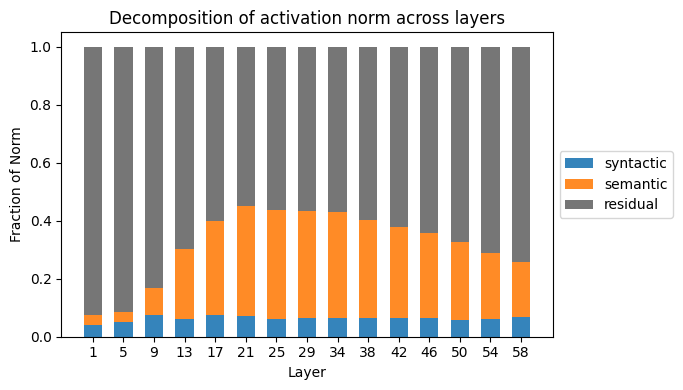

In [57]:
import matplotlib.pyplot as plt
import numpy as np

layer_vals = layers[::2]

syn_means = []
sem_means = []
residual_means = []

for layer in layer_vals:
    act_A, syn_centroids_A, sem_centroids_A, global_center_A = preprocessing(
        all_activations_A, 
        layer, 
        space_index='A',
        global_center_flag=global_center_flag,
        avg_tokens=avg_tokens,
    )

    fractions = projection_coefficients(act_A, syn_centroids_A, sem_centroids_A)

    syn_means.append(np.mean(np.array(fractions['syn'])))
    sem_means.append(np.mean(np.array(fractions['sem'])))
    residual_means.append(np.mean(np.array(fractions['residual'])))

# Convert to numpy arrays for easier stacking
syn_means = np.array(syn_means)
sem_means = np.array(sem_means)
residual_means = np.array(residual_means)

# Plot
fig, ax = plt.subplots(figsize=(6, 4))

bar_width = 0.6
x = np.arange(len(layer_vals))

ax.bar(x, syn_means, width=bar_width, color="#1f77b4", label="syntactic", alpha=0.9)
ax.bar(x, sem_means, width=bar_width, bottom=syn_means, color="#ff7f0e", label="semantic", alpha=0.9)
ax.bar(x, residual_means, width=bar_width, bottom=syn_means + sem_means, color="#676767", label="residual", alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(layer_vals)
ax.set_xlabel("Layer")
ax.set_ylabel("Fraction of Norm")
ax.set_title("Decomposition of activation norm across layers")


box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


plt.tight_layout()
plt.show()


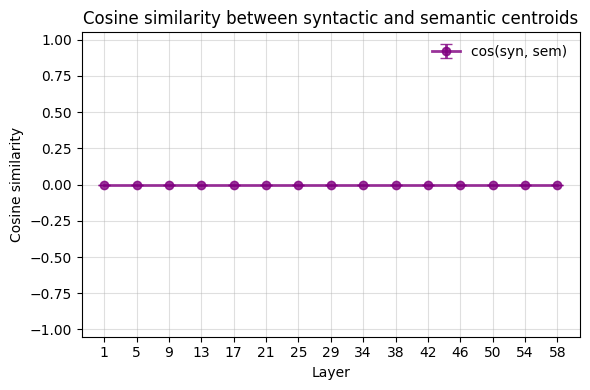

In [63]:
def cosine_similarity(a, b, eps=1e-12):
    """Compute cosine similarity per row between two (N, D) matrices."""
    dot = jnp.sum(a * b, axis=1)
    norm_a = jnp.linalg.norm(a, axis=1)
    norm_b = jnp.linalg.norm(b, axis=1)
    return dot / (norm_a * norm_b + eps)


# Collect cosine similarities per layer
cos_means = []
cos_stds = []

for layer in layer_vals:
    act_A, syn_centroids_A, sem_centroids_A, global_center_A = preprocessing(
        all_activations_A, 
        layer, 
        space_index='A',
        global_center_flag=global_center_flag,
        avg_tokens=avg_tokens,
    )
    syn_centroids_A = batched_remove_centroid_projections(syn_centroids_A,jnp.arange(sem_centroids_A.shape[0],dtype=jnp.int32),sem_centroids_A)

    cos = np.array(cosine_similarity(syn_centroids_A, sem_centroids_A))
    cos_means.append(cos.mean())
    cos_stds.append(cos.std())


# -------------------------------------------------------------------------
# Plot cosine similarity
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(layer_vals))

ax.errorbar(
    x, cos_means, yerr=cos_stds, 
    fmt='-o', capsize=4, lw=2,
    color='purple', alpha=0.8, 
    label='cos(syn, sem)'
)

ax.set_xticks(x)
ax.set_xticklabels(layer_vals)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine similarity")
ax.set_title("Cosine similarity between syntactic and semantic centroids")
ax.legend(frameon=False)
ax.grid(alpha=0.4)

ax.set_ylim(-1.05,1.05)

plt.tight_layout()
plt.show()
